In [189]:
!pip install shap

/tmp/ipykernel_2091/1074997373.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


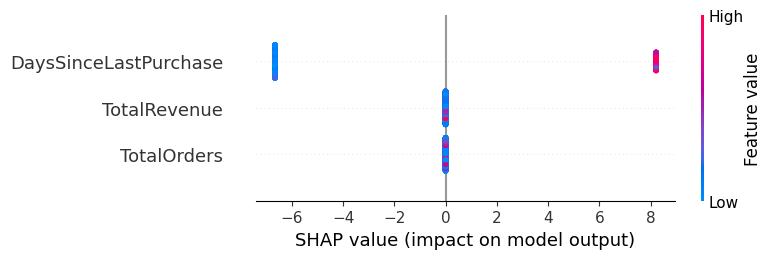

/tmp/ipykernel_2091/1074997373.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


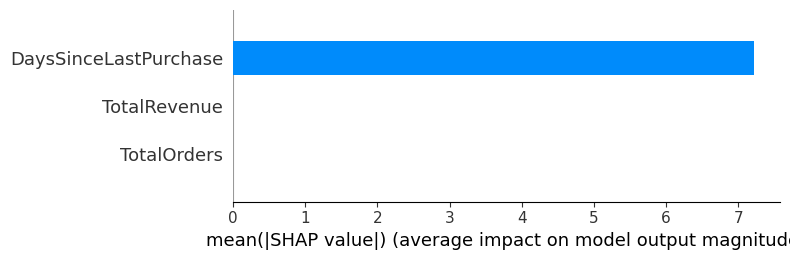

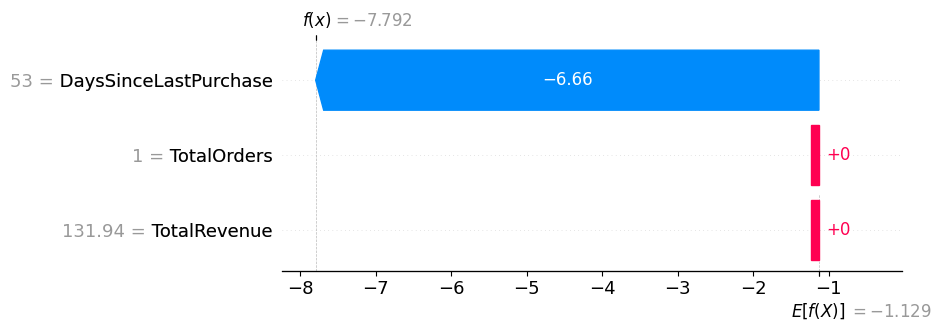

<Figure size 640x480 with 0 Axes>

In [190]:
#SHAP\
#import libraries
import shap
import matplotlib.pyplot as plt

#Create explainer
explainer = shap.TreeExplainer(
    model
)

#Calculate SHAP Values
shap_values = explainer.shap_values(
    X_test
)

#SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test
)

#Save
plt.savefig(
    "shap_summary.png",
    dpi=300,
    bbox_inches='tight'
)

#Feature Importance Plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)
plt.savefig(
    "shap_feature_importance.png",
    dpi=300,
    bbox_inches='tight'
)

#Waterfall Plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)
plt.savefig(
    "shap_waterfall.png",
    dpi=300,
    bbox_inches='tight'
)

In [191]:
#Interpret Results
# ==========================================
# SHAP FEATURE IMPORTANCE ANALYSIS
# ==========================================

import pandas as pd
import numpy as np

# Mean absolute SHAP value for each feature
feature_importance = pd.DataFrame({

    'Feature': X_test.columns,

    'Importance': np.abs(
        shap_values
    ).mean(axis=0)

})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance Ranking:\n")
print(feature_importance)

# Top Feature
top_feature = feature_importance.iloc[0]['Feature']

print("\nMost Important Feature:", top_feature)

# Automatic Interpretation
print("\nINTERPRETATION:")

if top_feature == 'Recency':
    print("""
Recency is the strongest factor affecting churn.
Customers who have not purchased recently are more likely to churn.
Recommendation:
Focus on re-engagement campaigns and retention offers.
""")

elif top_feature == 'Frequency':
    print("""
Frequency is the strongest factor affecting churn.
Customers who purchase less often are more likely to churn.
Recommendation:
Implement loyalty programs and repeat-purchase incentives.
""")

elif top_feature == 'Monetary':
    print("""
Monetary value is the strongest factor affecting churn.
Low-spending customers show higher churn probability.
Recommendation:
Increase customer engagement through personalized offers.
""")

elif top_feature == 'TotalRevenue':
    print("""
Total revenue is the strongest factor affecting churn.
Customers generating lower revenue are more likely to leave.
Recommendation:
Target low-value customers with retention campaigns.
""")

elif top_feature == 'TotalOrders':
    print("""
Total orders is the strongest factor affecting churn.
Customers with fewer orders are at higher risk.
Recommendation:
Encourage repeat purchases using discounts and loyalty rewards.
""")

else:
    print(f"""
{top_feature} is the strongest driver of churn.
Further business analysis is recommended.
""")


Feature Importance Ranking:

                 Feature  Importance
0  DaysSinceLastPurchase    7.215024
1            TotalOrders    0.000000
2           TotalRevenue    0.000000

Most Important Feature: DaysSinceLastPurchase

INTERPRETATION:

DaysSinceLastPurchase is the strongest driver of churn.
Further business analysis is recommended.



In [192]:
# Save SHAP importance table

feature_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

feature_importance

,Feature,Importance
0,DaysSinceLastPurchase,7.215024
1,TotalOrders,0.000000
2,TotalRevenue,0.000000


In [193]:
#Bussiness insight summary
top3 = feature_importance.head(3)

print("\nTOP 3 CHURN DRIVERS")

for i, row in top3.iterrows():
    print(
        f"{row['Feature']} "
        f"(Importance = {row['Importance']:.4f})"
    )


TOP 3 CHURN DRIVERS
DaysSinceLastPurchase (Importance = 7.2150)
TotalOrders (Importance = 0.0000)
TotalRevenue (Importance = 0.0000)
